# Linear Regression in Python with Scikit-Learn
---
## Exploratory Data Analysis
---

In [2]:
import pandas as pd
# Substitute the path_to_file content by the path to your student_scores.csv file 
path_to_file = 'student_scores.csv'
df = pd.read_csv(path_to_file)
df.head() 


,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [3]:
df.shape

(25, 2)

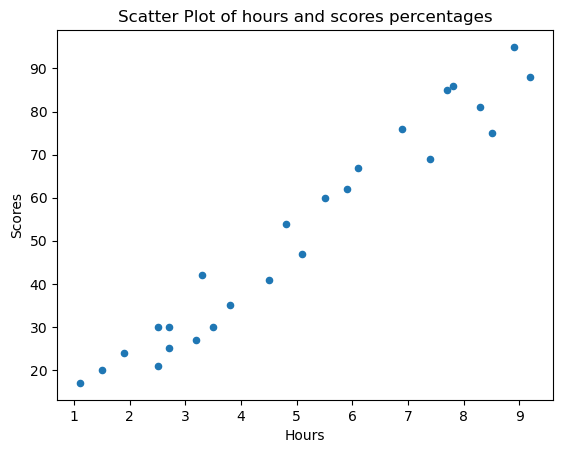

In [4]:
df.plot.scatter(x='Hours', y='Scores', title='Scatter Plot of hours and scores percentages');


In [5]:
print(df.corr())


           Hours    Scores
Hours   1.000000  0.976191
Scores  0.976191  1.000000


In [6]:
print(df.describe())


           Hours     Scores
count  25.000000  25.000000
mean    5.012000  51.480000
std     2.525094  25.286887
min     1.100000  17.000000
25%     2.700000  30.000000
50%     4.800000  47.000000
75%     7.400000  75.000000
max     9.200000  95.000000


---
## Linear Regression Theory

The equation that describes any straight line is:
y = a∗x + b

In this equation, y represents the score percentage, x represents the hours studied. b is where the line starts at the Y-axis, also called the Y-axis intercept and a defines if the line is going to be more towards the upper or lower part of the graph (the angle of the line), so it is called the slope of the line.

---
## Linear Regression with Python's Scikit-Learn

With the theory under our belts - let's get to implementing a Linear Regression algorithm with Python and the Scikit-Learn library! We'll start with a simpler linear regression and then expand onto multiple linear regression with a new dataset.

---
## Data Preprocessing

We have already imported Pandas, loaded our file into a DataFrame and plotted a graph to see if there was an indication of a linear relationship. Now, we can divide our data in two arrays - one for the dependent feature and one for the independent, or target feature. Since we want to predict the score percentage depending on the hours studied, our y will be the "Score" column and our X will the "Hours" column.

---

In [7]:
y = df['Scores'].values.reshape(-1, 1)
X = df['Hours'].values.reshape(-1, 1)

In [8]:
print(df['Hours'].values) 
print(df['Hours'].values.shape) 

[2.5 5.1 3.2 8.5 3.5 1.5 9.2 5.5 8.3 2.7 7.7 5.9 4.5 3.3 1.1 8.9 2.5 1.9
 6.1 7.4 2.7 4.8 3.8 6.9 7.8]
(25,)


In [9]:
print(X.shape) 
print(X)  

(25, 1)
[[2.5]
 [5.1]
 [3.2]
 [8.5]
 [3.5]
 [1.5]
 [9.2]
 [5.5]
 [8.3]
 [2.7]
 [7.7]
 [5.9]
 [4.5]
 [3.3]
 [1.1]
 [8.9]
 [2.5]
 [1.9]
 [6.1]
 [7.4]
 [2.7]
 [4.8]
 [3.8]
 [6.9]
 [7.8]]


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train)
print(y_train)

[[2.7]
 [3.3]
 [5.1]
 [3.8]
 [1.5]
 [3.2]
 [4.5]
 [8.9]
 [8.5]
 [3.5]
 [2.7]
 [1.9]
 [4.8]
 [6.1]
 [7.8]
 [5.5]
 [7.7]
 [1.1]
 [7.4]
 [9.2]]
[[25]
 [42]
 [47]
 [35]
 [20]
 [27]
 [41]
 [95]
 [75]
 [30]
 [30]
 [24]
 [54]
 [67]
 [86]
 [60]
 [85]
 [17]
 [69]
 [88]]


---
## Training a Linear Regression Model

We have our train and test sets ready. Scikit-Learn has a plethora of model types we can easily import and train, LinearRegression being one of them:

---

In [11]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print(regressor.intercept_)
print(regressor.coef_)

[2.82689235]
[[9.68207815]]


---
## Making Predictions

To avoid running calculations ourselves, we could write our own formula that calculates the value:

---

In [14]:
def calc(slope, intercept, hours):
    return slope*hours+intercept

score = calc(regressor.coef_, regressor.intercept_, 9.5)
print(score)

[[94.80663482]]


In [15]:
# Passing 9.5 in double brackets to have a 2 dimensional array
score = regressor.predict([[9.5]])
print(score)

[[94.80663482]]


In [16]:
y_pred = regressor.predict(X_test)
df_preds = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print(df_preds)

   Actual  Predicted
0      81  83.188141
1      30  27.032088
2      21  27.032088
3      76  69.633232
4      62  59.951153


---
## Evaluating the Model

After looking at the data, seeing a linear relationship, training and testing our model, we can understand how well it predicts by using some metrics. For regression models, three evaluation metrics are mainly used:

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)

---

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

Mean absolute error: 3.92
Mean squared error: 18.94
Root mean squared error: 4.35


---
## Multiple Linear Regression

Until this point, we have predicted a value with linear regression using only one variable. There is a different scenario that we can consider, where we can predict using many variables instead of one, and this is also a much more common scenario in real life, where many things can affect some result.

---
## Exploratory Data Analysis

To get a practical sense of multiple linear regression, let's keep working with our gas consumption example, and use a dataset that has gas consumption data on 48 US States.

---

In [18]:
file = 'petrol_consumption.csv'
df = pd.read_csv(file)
df.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [19]:
df.shape

(48, 5)

In [20]:
print(df.describe().round(2).T)

                              count     mean      std      min      25%  \
Petrol_tax                     48.0     7.67     0.95     5.00     7.00   
Average_income                 48.0  4241.83   573.62  3063.00  3739.00   
Paved_Highways                 48.0  5565.42  3491.51   431.00  3110.25   
Population_Driver_licence(%)   48.0     0.57     0.06     0.45     0.53   
Petrol_Consumption             48.0   576.77   111.89   344.00   509.50   

                                  50%      75%       max  
Petrol_tax                       7.50     8.12     10.00  
Average_income                4298.00  4578.75   5342.00  
Paved_Highways                4735.50  7156.00  17782.00  
Population_Driver_licence(%)     0.56     0.60      0.72  
Petrol_Consumption             568.50   632.75    968.00  


---

This time, we will use **Seaborn**, an extension of Matplotlib which Pandas uses under the hood when plotting:

---

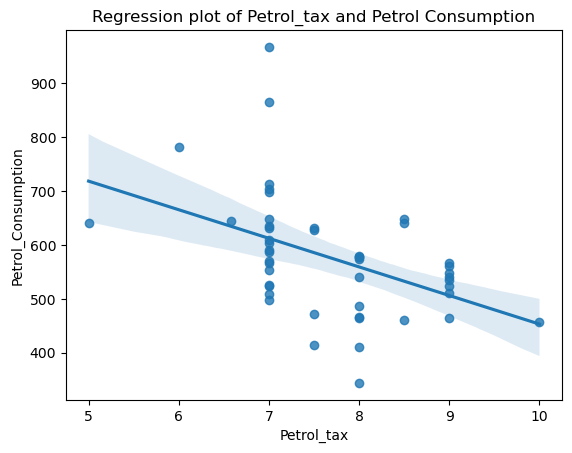

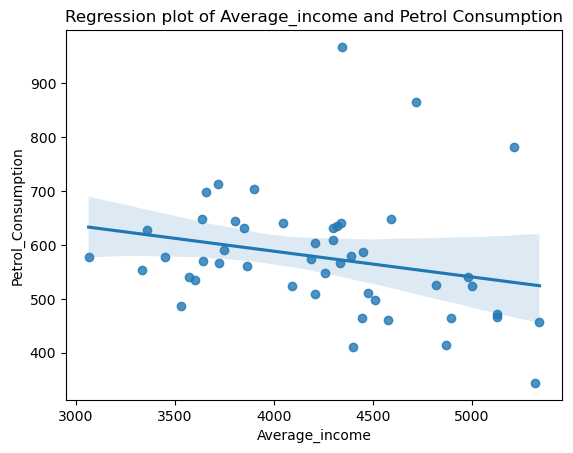

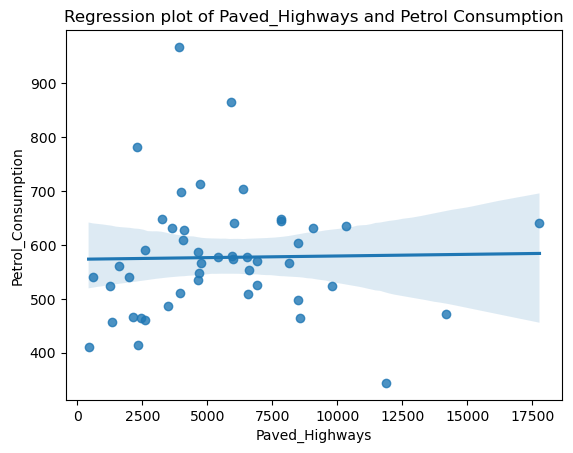

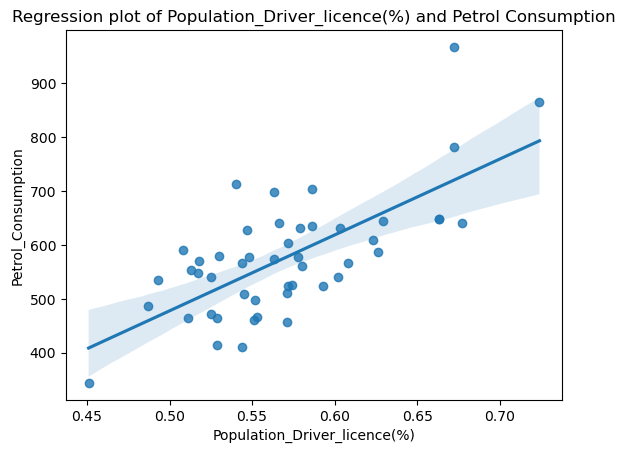

In [22]:
import seaborn as sns # Convention alias for Seaborn
import matplotlib.pyplot as plt
variables = ['Petrol_tax', 'Average_income', 'Paved_Highways','Population_Driver_licence(%)']

for var in variables:
    plt.figure() # Creating a rectangle (figure) for each plot
    # Regression Plot also by default includes
    # best-fitting regression line
    # which can be turned off via `fit_reg=False`
    sns.regplot(x=var, y='Petrol_Consumption', data=df).set(title=f'Regression plot of {var} and Petrol Consumption');

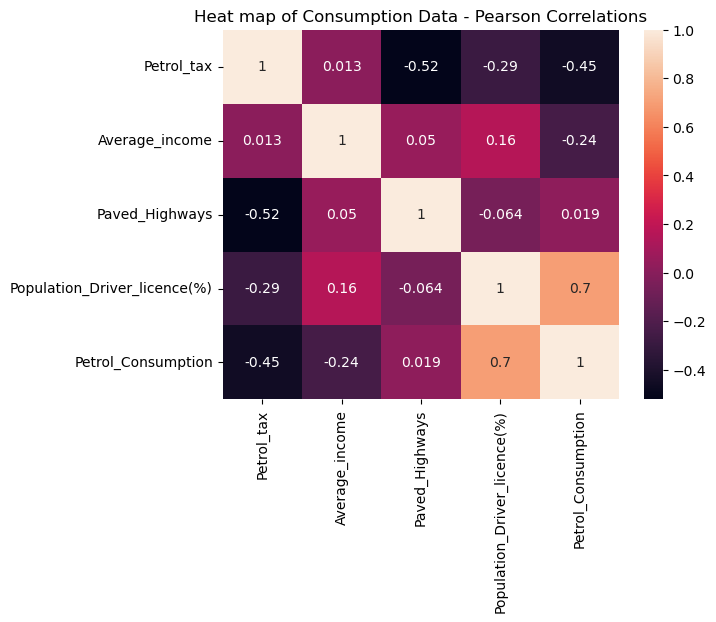

In [23]:
correlations = df.corr()
# annot=True displays the correlation values
sns.heatmap(correlations, annot=True).set(title='Heat map of Consumption Data - Pearson Correlations');